## 1. Import Libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

plt.style.use('seaborn-v0_8-darkgrid')
SEED = 42
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load Dataset

We load the **Cleveland Heart Disease** dataset directly from the UCI repository.  
- 303 samples, 13 features + 1 target
- Missing values are encoded as `?`

In [12]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=columns, na_values='?')

# Binarise target: 0 = no disease, 1 = disease
df['target'] = (df['target'] > 0).astype(int)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Exploratory Data Analysis (EDA)

In [13]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


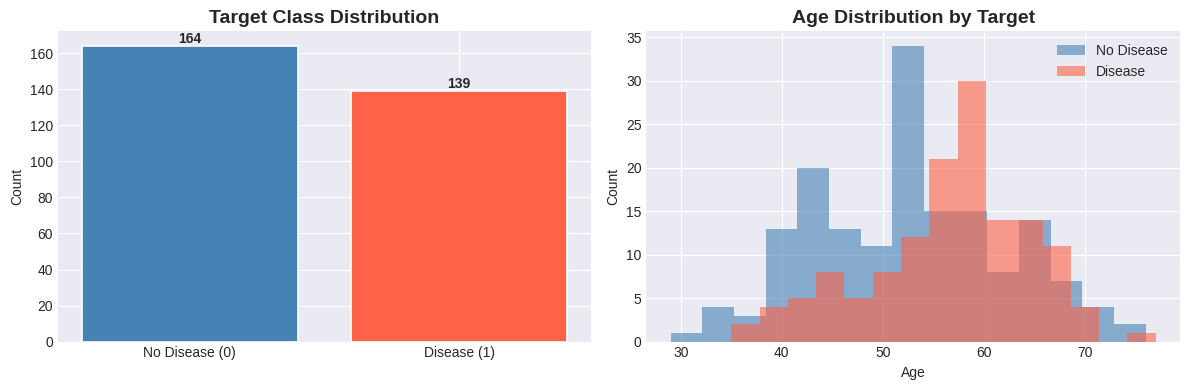

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Age distribution by target
df[df['target'] == 0]['age'].hist(ax=axes[1], alpha=0.6, label='No Disease', color='steelblue', bins=15)
df[df['target'] == 1]['age'].hist(ax=axes[1], alpha=0.6, label='Disease',    color='tomato',    bins=15)
axes[1].set_title('Age Distribution by Target', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

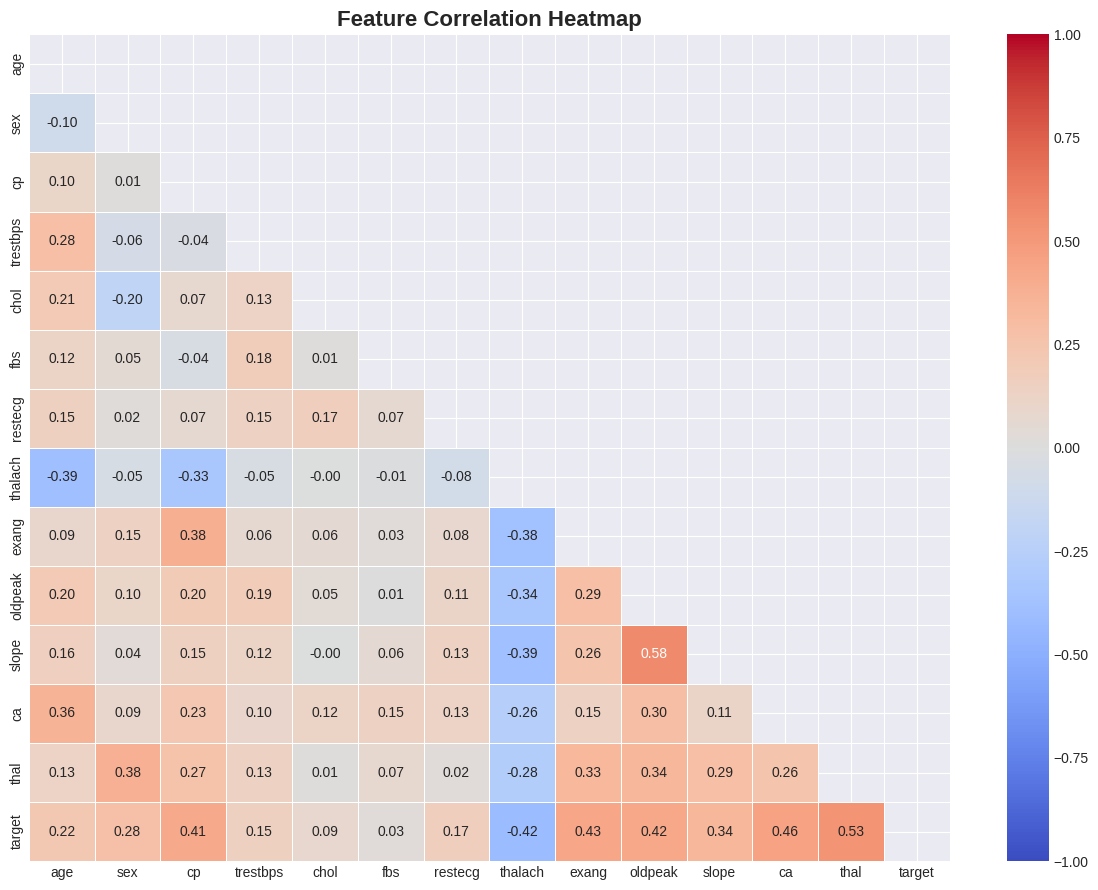

In [15]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [16]:
# 4.1 Handle missing values — replace with column median
print('Missing values before:', df.isnull().sum().sum())
df.fillna(df.median(numeric_only=True), inplace=True)
print('Missing values after: ', df.isnull().sum().sum())

# 4.2 Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# 4.3 Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# 4.4 Normalise continuous features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nTrain size: {X_train.shape[0]}   Test size: {X_test.shape[0]}')
print(f'Train class balance:\n{y_train.value_counts()}')

Missing values before: 6
Missing values after:  0

Train size: 242   Test size: 61
Train class balance:
target
0    131
1    111
Name: count, dtype: int64


## 5. Model Training

We train four classifiers and compare them:
1. Logistic Regression (baseline)
2. Decision Tree
3. K-Nearest Neighbors
4. Random Forest (primary)

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree':       DecisionTreeClassifier(random_state=SEED),
    'KNN':                 KNeighborsClassifier(),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=SEED),
}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision':precision_score(y_test, y_pred),
        'recall':   recall_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_proba),
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
    }
    print(f'{name:22s} | Accuracy: {results[name]["accuracy"]:.3f} | CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

Logistic Regression    | Accuracy: 0.869 | CV: 0.826 ± 0.053
Decision Tree          | Accuracy: 0.721 | CV: 0.744 ± 0.057
KNN                    | Accuracy: 0.885 | CV: 0.843 ± 0.044
Random Forest          | Accuracy: 0.885 | CV: 0.806 ± 0.041


## 6. Hyperparameter Tuning — Random Forest

In [18]:
param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_sc, y_train)

best_rf   = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_sc)
y_prob_rf = best_rf.predict_proba(X_test_sc)[:, 1]

print('\nBest Parameters:', grid_search.best_params_)
print(f'Tuned RF Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Tuned RF F1-Score : {f1_score(y_test, y_pred_rf):.4f}')
print(f'Tuned RF ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}')

# Update results
results['Random Forest (Tuned)'] = {
    'model':    best_rf,
    'y_pred':   y_pred_rf,
    'y_proba':  y_prob_rf,
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision':precision_score(y_test, y_pred_rf),
    'recall':   recall_score(y_test, y_pred_rf),
    'f1':       f1_score(y_test, y_pred_rf),
    'roc_auc':  roc_auc_score(y_test, y_prob_rf),
    'cv_mean':  grid_search.best_score_,
    'cv_std':   0,
}

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Tuned RF Accuracy : 0.9016
Tuned RF F1-Score : 0.8966
Tuned RF ROC-AUC  : 0.9481


## 7. Evaluation & Visualisation

In [19]:
# Metrics comparison table
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  round(v['accuracy'],  4),
        'Precision': round(v['precision'], 4),
        'Recall':    round(v['recall'],    4),
        'F1-Score':  round(v['f1'],        4),
        'ROC-AUC':   round(v['roc_auc'],   4),
    }
    for name, v in results.items()
}).T

print('=== Model Comparison ===')
metrics_df.style.highlight_max(color='lightgreen', axis=0)

=== Model Comparison ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.868900,0.812500,0.928600,0.866700,0.951300
Decision Tree,0.721300,0.657100,0.821400,0.730200,0.728900
KNN,0.885200,0.800000,1.000000,0.888900,0.923200
Random Forest,0.885200,0.818200,0.964300,0.885200,0.951300
Random Forest (Tuned),0.901600,0.866700,0.928600,0.896600,0.948100


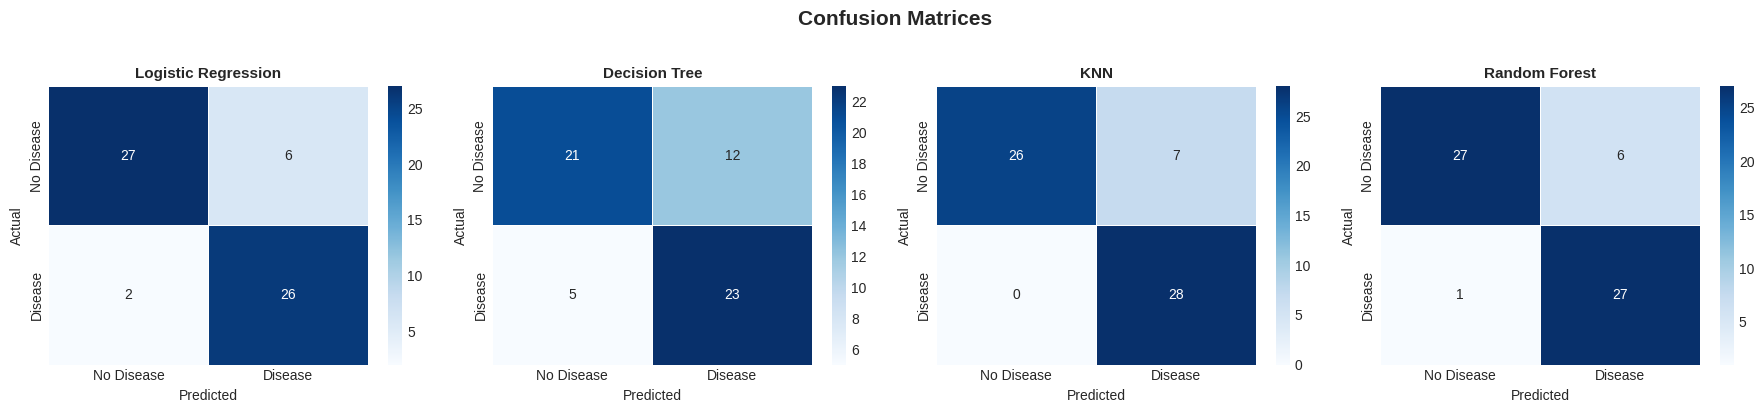

In [20]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
base_models = ['Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest']

for ax, name in zip(axes, base_models):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=0.5)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

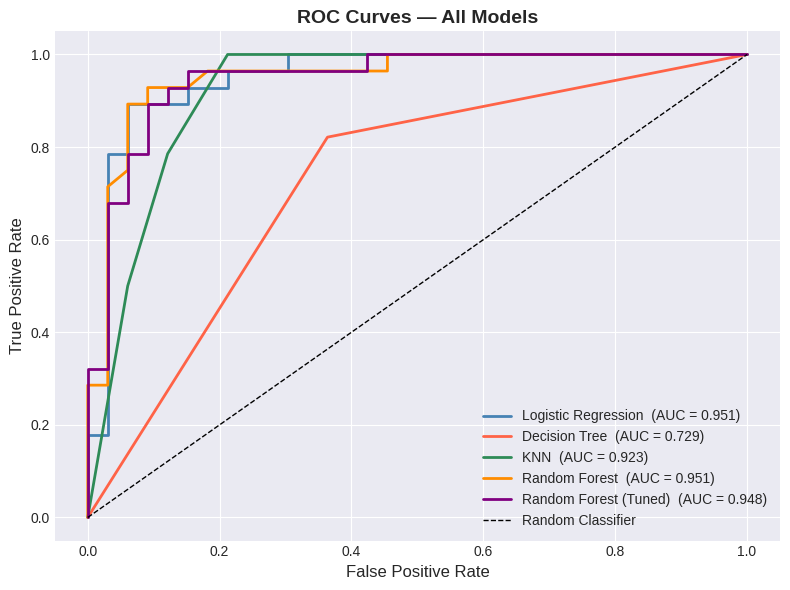

In [21]:
# ROC Curves
plt.figure(figsize=(8, 6))
colours = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'purple']

for (name, v), colour in zip(results.items(), colours):
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    plt.plot(fpr, tpr, lw=2, color=colour,
             label=f"{name}  (AUC = {v['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

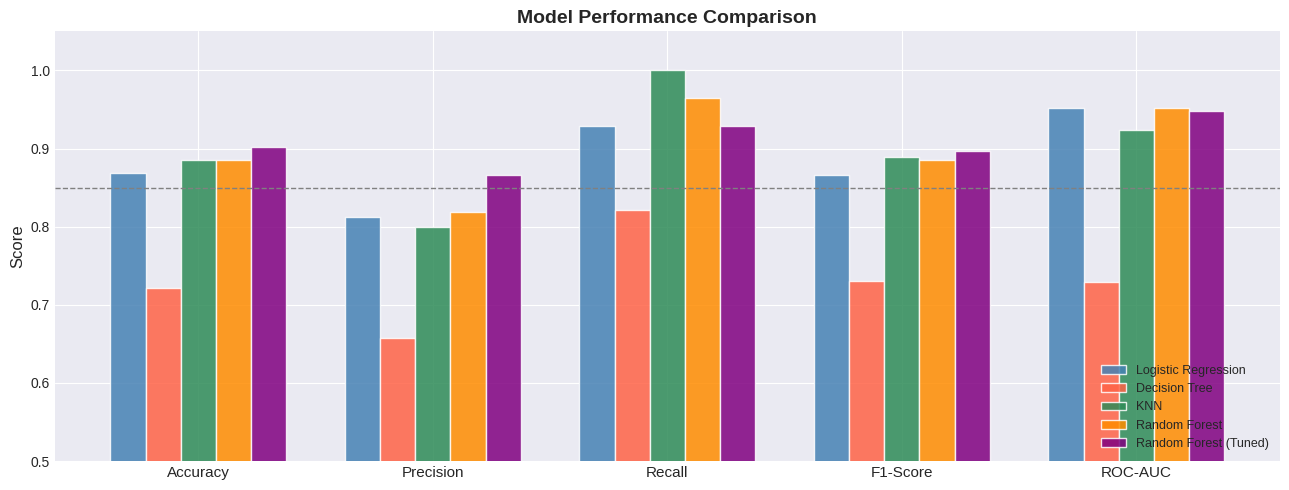

In [22]:
# Bar chart comparison
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metric_cols))
width = 0.15
colours = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'purple']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, row) in enumerate(metrics_df.iterrows()):
    ax.bar(x + i * width, row[metric_cols].values, width,
           label=name, color=colours[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.axhline(y=0.85, color='gray', linestyle='--', linewidth=1, label='85% target')
plt.tight_layout()
plt.show()

## 8. Feature Importance (Random Forest)

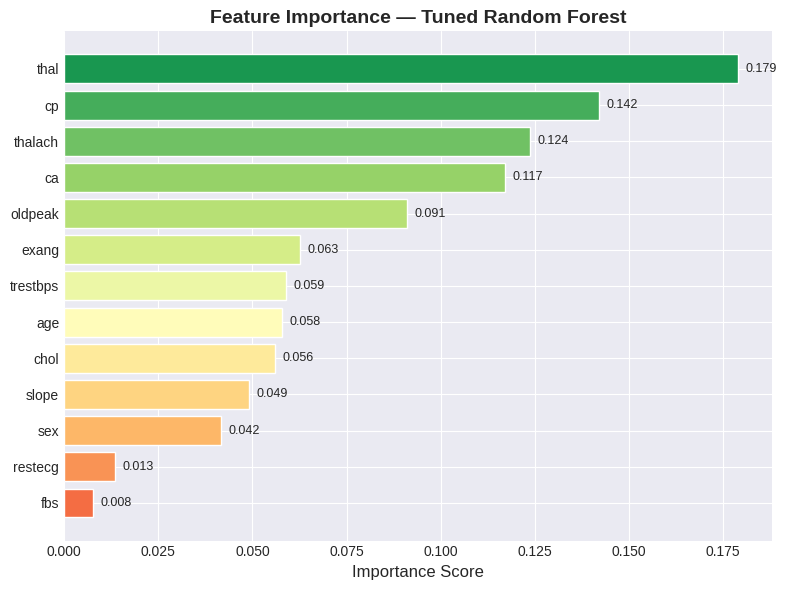

In [23]:
importances = best_rf.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
colours = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
bars = plt.barh(feat_df['Feature'], feat_df['Importance'], color=colours, edgecolor='white')

for bar, val in zip(bars, feat_df['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)

plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Classification Report — Best Model

In [24]:
print('=== Classification Report: Tuned Random Forest ===')
print(classification_report(
    y_test, results['Random Forest (Tuned)']['y_pred'],
    target_names=['No Disease', 'Disease']
))

=== Classification Report: Tuned Random Forest ===
              precision    recall  f1-score   support

  No Disease       0.94      0.88      0.91        33
     Disease       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

